## Imports

In [2]:

import sys
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import numpy as np
import logging
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import scanpy as sc
import muon as mu

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
DATA_DIR = PROJECT_DIR / "cached_data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "testing_results"

output_dir = PROJECT_DIR / "mouse_development_testing"

sys.path.append(str(PROJECT_DIR))

import warnings

if torch.cuda.is_available():
    device = torch.device("cuda")
    logging.info(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
else:
    device = torch.device("cpu")
    logging.info("Using CPU")

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

font_path = PROJECT_DIR / "fonts" / "Arial.ttf"

fm.fontManager.addfont(font_path)
arial_font = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [arial_font, "Helvetica", "Liberation Sans", "DejaVu Sans"]

logging.info(f"Using font: {arial_font}")

rng = np.random.default_rng()

INFO - Using CPU
INFO - Using font: Arial


## Labeling Cell Lineages


### Load Muon Data
Does the model, when trained using hepatocyte data, correctly identify lineage-specific signaling in mouse embryonic cells? To test this, I first need to load in the muon h5mu file for the sample. We will re-normalize the raw counts for getting the cell lineages.

In [3]:
def load_muon_data(cell_type, sample_name):
    mudata_path = Path(f"/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/sample_input_data/{cell_type}/{sample_name}/multiome_processed.h5mu")
    
    mudata = mu.read_h5mu(mudata_path)
    return mudata

e85_expression = load_muon_data("mESC", "E8.5_rep1")
rna = e85_expression["rna"]
rna_de = rna.copy()

# Re-normalize the raw counts
rna_de.X = rna_de.layers["counts"].copy()
sc.pp.normalize_total(rna_de,target_sum=1e4)
# sc.pp.log1p(rna_de)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### Rank gene groups

Next we will get the marker genes between the groups, based on the `leiden` attribute.

In [4]:
sc.tl.rank_genes_groups(
    rna_de,
    groupby="leiden",
    reference="rest",
    method="wilcoxon",
    use_raw=False,
    pts=True,
    key_added="leiden_markers"
)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_g

In [5]:
all_clusters = rna_de.obs["leiden"].unique().tolist()

# Get the top 15 markers per cluster
summary = {}
for cluster in all_clusters:
    df = sc.get.rank_genes_groups_df(
        rna_de,
        group=cluster,
        key="leiden_markers"
    ).copy()
    
    # Only return significant marker genes
    df = df[
        (df["scores"] > 0) &
        (df["pvals_adj"] < 0.05)
    ]

    # Set a specificity score based on how expressed the gene is 
    # in the cluster vs the rest of the cells
    df["specificity"] = (
        df["pct_nz_group"] - df["pct_nz_reference"]
    )

    # Combine statistical rank and specificity
    df = df.sort_values(
        ["scores", "specificity"],
        ascending=False
    )

    summary[cluster] = df["names"].head(15).tolist()
    
for cluster, genes in summary.items():
    print(f"Cluster {cluster}: {', '.join(genes)}")

Cluster 0: Kdr, Fli1, Plvap, Egfl7, Flt1, Shank3, Elk3, Igfbp4, Tek, Ramp2, Flt4, Rhoj, Arap3, Vav3, Ptprm
Cluster 1: Ptn, Mast4, Npas3, Adgrv1, Sox2ot, Car10, Ctnna2, Fgf15, Fst, Slc35f1, Zfp423, Efna5, Ptpn13, Fmn2, Epha4
Cluster 2: Rspo3, Dll1, Lef1, Smc6, Dll3, Pcdh19, Kif26b, Smoc1, Rftn1, Tmem132c, Rnf213, Mllt3, Epha4, Laptm4b, Hoxd4
Cluster 5: Hbb-bh1, Hba-x, Hba-a1, Fth1, Rplp0, Abcb10, Hba-a2, Rps9, Gpx1, Reln, Frrs1, Blvrb, Mir142hg, Sptb, Slc25a21
Cluster 6: Pmp22, Dlk1, Nrp1, Ahnak, Ece1, Igf2, Col1a2, Tmem108, Podxl, Stard8, Mest, Prdm6, Col5a2, Serpinh1, Pcdh7
Cluster 7: Wnt6, Slc2a3, Bcam, Frem2, Dag1, Epcam, Cdh3, Spint2, Npnt, Cdh1, Esrp1, Hapln1, Cldn6, F11r, Wls
Cluster 9: Otx2, Cdh20, Epha7, Irs4, Six3, Rmst, Adgrv1, Kif21a, Rgma, Lrp2, Tenm4, Tmem47, Ank2, Pcsk1n, Cdh6
Cluster 10: Fbn2, Ntn1, Pdgfra, Fst, Meis2, Foxp2, Meox1, Fbxl7, Aff3, Tcf15, Cadm1, Aldh1a2, Sdk1, Sim1, Cdh11
Cluster 11: Sfmbt2, Phlda2, Mt2, Rhox5, Gjb3, Cdh1, Trap1a, Fabp3, Mt1, Klhl13, Epcam,

### Assign cell lineages based on the marker genes

In [6]:
cluster_to_lineage = {
    "0":  "Endothelial",
    "1":  "Neural ectoderm",
    "2":  "Presomitic mesoderm",
    "3":  "Nascent/posterior mesoderm",
    "4":  "Cranial/pharyngeal mesoderm",
    "5":  "Primitive erythroid",
    "6":  "Extraembryonic mesoderm",
    "7":  "Amniotic/surface ectoderm",
    "8":  "Surface/placodal ectoderm",
    "9":  "Anterior neural ectoderm",
    "10": "Somitic/paraxial mesoderm",
    "11": "Trophoblast/extraembryonic ectoderm",
    "12": "Primitive erythroid",
    "13": "Definitive/gut endoderm",
    "14": "Posterior extraembryonic mesoderm",
    "15": "Lateral plate mesoderm",
    "16": "Midbrain-hindbrain neural ectoderm",
    "17": "Allantoic mesoderm",
    "18": "Parietal endoderm",
    "19": "Neural tube",
    "20": "NMP",
    "21": "Ventral spinal cord",
    "22": "Neural crest",
    "23": "Visceral/yolk-sac endoderm",
    "24": "Cardiomyocyte",
}

cluster_to_broad_lineage = {
    "0":  "Mesoderm",          # Endothelial
    "1":  "Ectoderm",          # Neural ectoderm
    "2":  "Mesoderm",          # Presomitic mesoderm
    "3":  "Mesoderm",          # Nascent/posterior mesoderm
    "4":  "Mesoderm",          # Cranial/pharyngeal mesoderm
    "5":  "Hematopoietic",     # Primitive erythroid
    "6":  "Extraembryonic",    # Extraembryonic mesoderm
    "7":  "Ectoderm",          # Amniotic/surface ectoderm
    "8":  "Ectoderm",          # Surface/placodal ectoderm
    "9":  "Ectoderm",          # Anterior neural ectoderm
    "10": "Mesoderm",          # Somitic/paraxial mesoderm
    "11": "Extraembryonic",    # Trophoblast/extraembryonic ectoderm
    "12": "Hematopoietic",     # Primitive erythroid
    "13": "Endoderm",          # Definitive/gut endoderm
    "14": "Extraembryonic",    # Posterior extraembryonic mesoderm
    "15": "Mesoderm",          # Lateral plate mesoderm
    "16": "Ectoderm",          # Midbrain-hindbrain neural ectoderm
    "17": "Extraembryonic",    # Allantoic mesoderm
    "18": "Extraembryonic",    # Parietal endoderm
    "19": "Ectoderm",          # Neural tube
    "20": "Ectoderm",          # NMP
    "21": "Ectoderm",          # Ventral spinal cord
    "22": "Ectoderm",          # Neural crest
    "23": "Extraembryonic",    # Visceral/yolk-sac endoderm
    "24": "Mesoderm",          # Cardiomyocyte
}

rna.obs["fine_lineage"] = (
    rna.obs["leiden"]
    .astype(str)
    .map(cluster_to_lineage)
)

rna.obs["broad_lineage"] = (
    rna.obs["leiden"]
    .astype(str)
    .map(cluster_to_broad_lineage)
)

rna.obs["fine_lineage"] = pd.Categorical(rna.obs["fine_lineage"])
rna.obs["broad_lineage"] = pd.Categorical(rna.obs["broad_lineage"])

### UMAP of labeled cell lineages

#### Fine Lineages

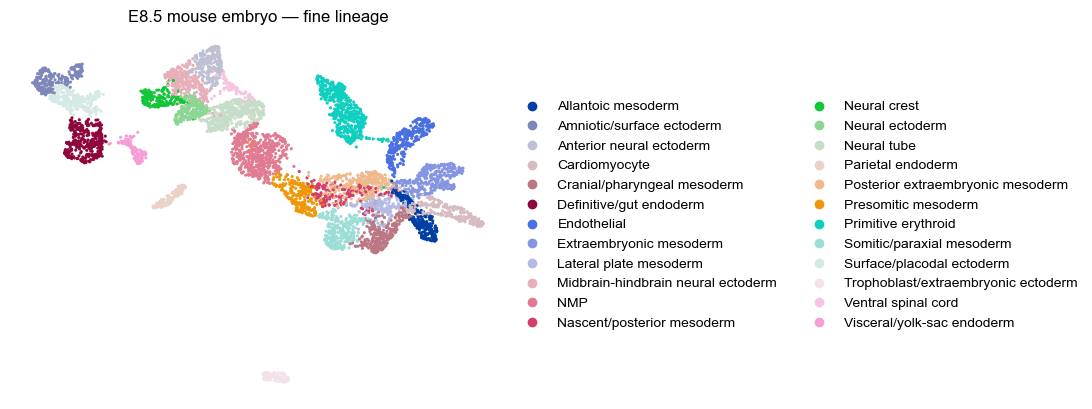

In [7]:
rna.obs[["leiden", "fine_lineage"]].drop_duplicates().sort_values("leiden")

sc.pl.umap(
    rna,
    color="fine_lineage",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — fine lineage"
)

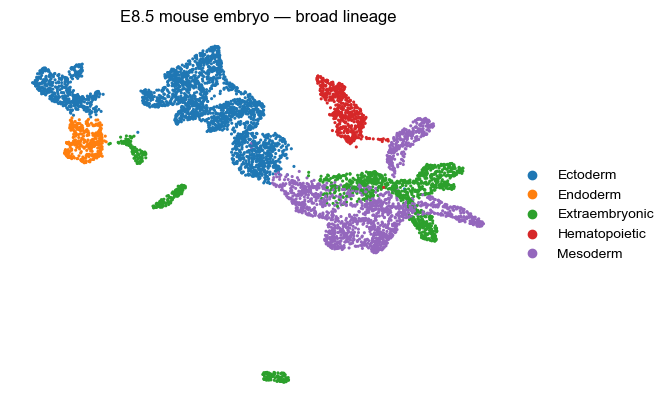

In [8]:
rna.obs[["leiden", "broad_lineage"]].drop_duplicates().sort_values("leiden")

sc.pl.umap(
    rna,
    color="broad_lineage",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — broad lineage"
)

### Dot Plot of Marker Genes by Broad Category

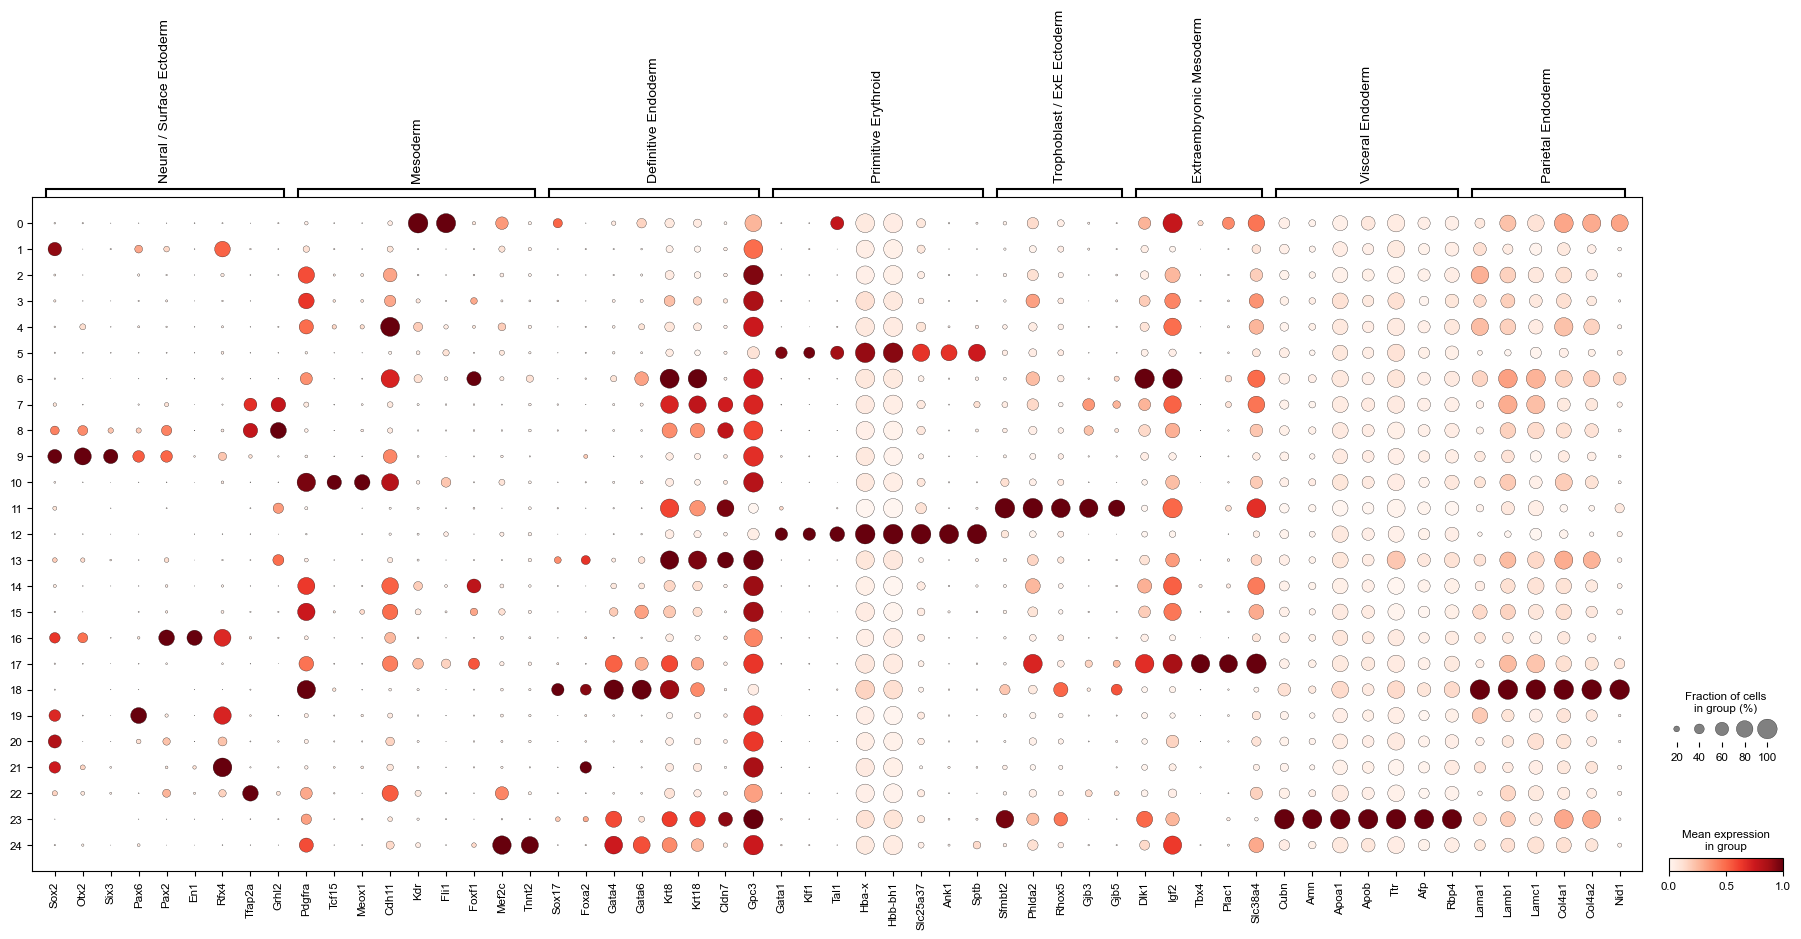

In [9]:
marker_groups = {
    "Neural / Surface Ectoderm": [
        "Sox2", "Otx2", "Six3", "Pax6",
        "Pax2", "En1", "Rfx4",
        "Tfap2a", "Grhl2",
    ],

    "Mesoderm": [
        "Pdgfra", "Tcf15", "Meox1",
        "Cdh11", "Kdr", "Fli1",
        "Foxf1", "Mef2c", "Tnnt2",
    ],

    "Definitive Endoderm": [
        "Sox17", "Foxa2", "Gata4", "Gata6",
        "Krt8", "Krt18", "Cldn7", "Gpc3",
    ],

    "Primitive Erythroid": [
        "Gata1", "Klf1", "Tal1",
        "Hba-x", "Hbb-bh1", "Slc25a37",
        "Ank1", "Sptb",
    ],

    "Trophoblast / ExE Ectoderm": [
        "Sfmbt2", "Phlda2", "Rhox5",
        "Gjb3", "Gjb5",
    ],

    "Extraembryonic Mesoderm": [
        "Dlk1", "Igf2", "Tbx4",
        "Plac1", "Slc38a4",
    ],

    "Visceral Endoderm": [
        "Cubn", "Amn", "Apoa1",
        "Apob", "Ttr", "Afp", "Rbp4",
    ],

    "Parietal Endoderm": [
        "Lama1", "Lamb1", "Lamc1",
        "Col4a1", "Col4a2", "Nid1",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in marker_groups.items()
}

# Remove empty marker groups
marker_groups = {
    group: genes
    for group, genes in marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

#### NMP Marker Genes

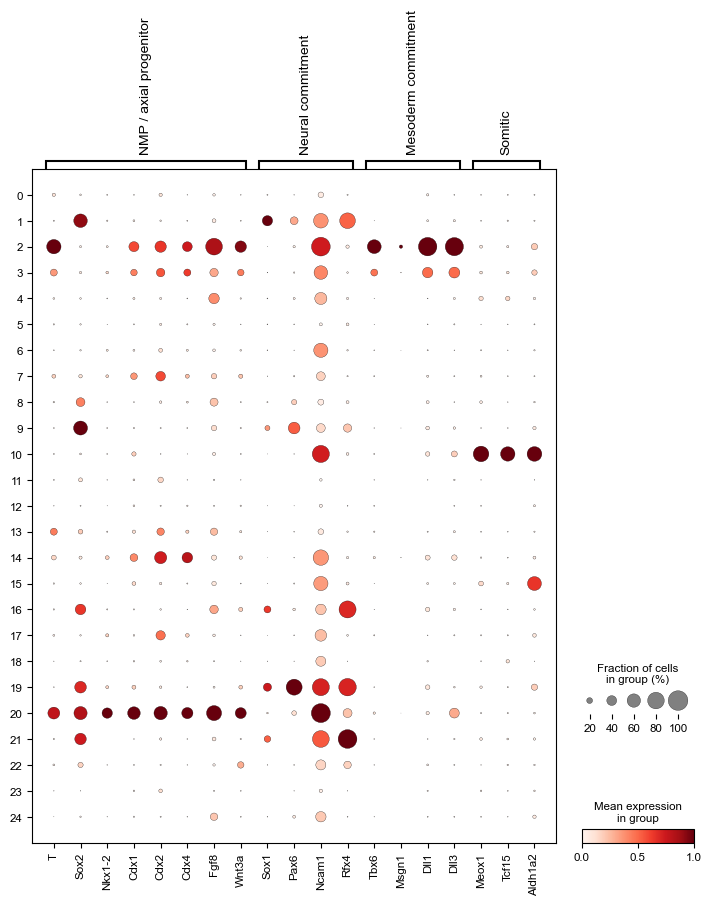

In [10]:
nmp_marker_groups = {
    "NMP / axial progenitor": [
        "T",
        "Sox2",
        "Nkx1-2",
        "Cdx1",
        "Cdx2",
        "Cdx4",
        "Fgf8",
        "Wnt3a",
    ],

    "Neural commitment": [
        "Sox1",
        "Pax6",
        "Ncam1",
        "Rfx4",
    ],

    "Mesoderm commitment": [
        "Tbx6",
        "Msgn1",
        "Dll1",
        "Dll3",
    ],

    "Somitic": [
        "Meox1",
        "Tcf15",
        "Aldh1a2",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
nmp_marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in nmp_marker_groups.items()
}

# Remove empty marker groups
nmp_marker_groups = {
    group: genes
    for group, genes in nmp_marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    nmp_marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

Cluster 20 has strong expression of NMP/posterior axial progenitor genes. Clusters 19 and 21 have strong expression of neural committment genes. From the previous marker genes, cluster 21 has strong evidence for ventralization due to Nkx6-1 and Hedgehog-response genes such as Ptch1. Cluster 19 is likely spinal cord / neural tube progenitor cells. 

### Plot of NMP differentiation

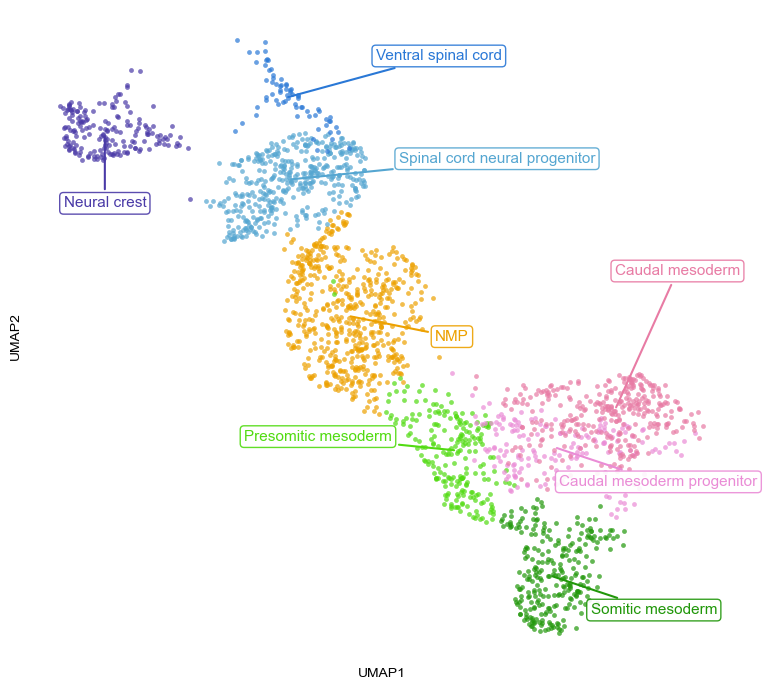

In [11]:
developmental_cluster_map = {
    "20": "NMP",
    "19": "Spinal cord neural progenitor",
    "21": "Ventral spinal cord",

    "2":  "Presomitic mesoderm",
    "10": "Somitic mesoderm",

    "3":  "Caudal mesoderm progenitor",
    "14": "Caudal mesoderm",

    "22": "Neural crest",
}

lineage_cols = {
    "NMP": "#eda100",
    "Spinal cord neural progenitor": "#55a6d1",
    "Ventral spinal cord": "#2a78d6",
    "Presomitic mesoderm": "#51db11",
    "Somitic mesoderm": "#21970a",
    "Caudal mesoderm progenitor": "#ea8cd6",
    "Caudal mesoderm": "#e87ba4",
    "Neural crest": "#4a3aa7",
}

# Clusters to include
clusters_to_plot = list(developmental_cluster_map.keys())

# Subset cells
rna_dev = rna_de[
    rna_de.obs["leiden"].astype(str).isin(clusters_to_plot)
].copy()

# Assign developmental lineage
rna_dev.obs["developmental_lineage"] = (
    rna_dev.obs["leiden"]
    .astype(str)
    .map(developmental_cluster_map)
)

# UMAP coordinates
umap = rna_dev.obsm["X_umap"]

fig, ax = plt.subplots(figsize=(8, 7))

# Plot each developmental lineage separately
for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    ax.scatter(
        umap[mask, 0],
        umap[mask, 1],
        s=12,
        alpha=0.7,
        c=color,
        label=lineage.replace("_", " "),
        linewidths=0,
    )

# Add developmental lineage labels with lines pointing
# to the median UMAP position of each lineage
label_offsets = {
    "NMP": (75, -15),
    "Spinal cord neural progenitor": (150, 15),
    "Ventral spinal cord": (110, 30),
    "Presomitic mesoderm": (-100, 10),
    "Somitic mesoderm": (75, -25),
    "Caudal mesoderm progenitor": (75, -25),
    "Caudal mesoderm": (45, 100),
    "Neural crest": (0, -50),
}

for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    if not mask.any():
        continue

    # Median location of all cells belonging to this lineage
    x = np.median(umap[mask, 0])
    y = np.median(umap[mask, 1])

    offset = label_offsets.get(lineage, (30, 30))

    ax.annotate(
        lineage.replace("_", " "),
        xy=(x, y),                  # point the line to this location
        xytext=offset,              # label offset in points
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=color,
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            linewidth=1.5,
        ),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=color,
            alpha=0.9,
        ),
    )

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# ax.legend(
#     title="Developmental lineage",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False,
# )

ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

### ForceAtlas2 Layout

In [33]:
import networkx as nx

# subset data to developmental lineage clusters
clusters_to_plot = list(developmental_cluster_map.keys())

rna_dev = rna_de[
    rna_de.obs["leiden"].astype(str).isin(clusters_to_plot)
].copy()

rna_dev.obs["developmental_lineage"] = (
    rna_dev.obs["leiden"]
    .astype(str)
    .map(developmental_cluster_map)
)

# Get the kNN connectivities
connectivities = (
    rna_dev.obsp["connectivities"]
    .tocsr()
    .copy()
)

# Make symmetric and remove self-edges
connectivities = connectivities.maximum(connectivities.T)

connectivities.setdiag(0)
connectivities.eliminate_zeros()

# Convert to NetworkX
G = nx.from_scipy_sparse_array(
    connectivities,
    create_using=nx.Graph,
    edge_attribute="weight",
)


In [34]:
# Run ForceAtlas2
pos = nx.forceatlas2_layout(
    G,
    max_iter=100,
    scaling_ratio=2.0,
    gravity=1.0,
    weight="weight",
    seed=42,
)

# Convert dictionary to an array matching rna_dev.obs order
forceatlas = np.array([
    pos[i]
    for i in range(rna_dev.n_obs)
])

# Save in AnnData
rna_dev.obsm["X_forceatlas2"] = forceatlas

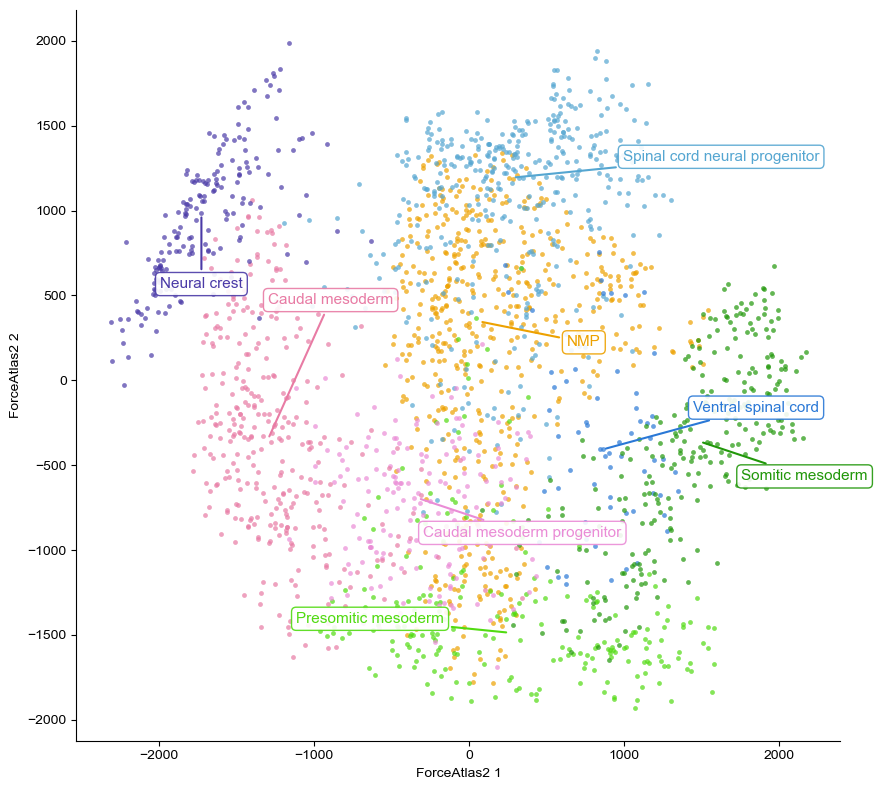

In [14]:

# -------------------------------------------------------
# 5. Plot ForceAtlas2 layout
# -------------------------------------------------------

coords = rna_dev.obsm["X_forceatlas2"]

fig, ax = plt.subplots(figsize=(9, 8))

for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        s=12,
        alpha=0.7,
        c=color,
        linewidths=0,
        label=lineage.replace("_", " "),
    )

# -------------------------------------------------------
# 6. Add lineage labels
# -------------------------------------------------------
for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    if not mask.any():
        continue

    # Median ForceAtlas2 position
    x = np.median(coords[mask, 0])
    y = np.median(coords[mask, 1])

    ax.annotate(
        lineage.replace("_", " "),
        xy=(x, y),
        xytext=label_offsets.get(lineage, (30, 30)),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=color,
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            linewidth=1.5,
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor=color,
            alpha=0.9,
        ),
    )


ax.set_xlabel("ForceAtlas2 1")
ax.set_ylabel("ForceAtlas2 2")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Direct labels make the legend optional
# ax.legend(
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False,
# )

plt.tight_layout()
plt.show()

In [15]:
import scipy.sparse as sp

genes = ["T", "Sox2", "Tbx6", "Msgn1"]

for gene in genes:
    if gene not in rna_dev.var_names:
        continue

    x = rna_dev[:, gene].X
    v = x.toarray().ravel() if sp.issparse(x) else np.asarray(x).ravel()

    df = pd.DataFrame({
        "expression": v,
        "lineage": rna_dev.obs["developmental_lineage"].values,
    })

    summary = (
        df.groupby("lineage", observed=True)
        .agg(
            mean_expression=("expression", "mean"),
            pct_expressing=("expression", lambda x: (x > 0).mean()),
        )
        .sort_values("mean_expression", ascending=False)
    )

    print(f"\n===== {gene} =====")
    print(summary.round(3).to_string())


===== T =====
                               mean_expression  pct_expressing
lineage                                                       
Presomitic mesoderm                      2.278           0.661
NMP                                      1.798           0.514
Caudal mesoderm progenitor               0.817           0.251
Caudal mesoderm                          0.357           0.153
Neural crest                             0.088           0.044
Ventral spinal cord                      0.082           0.029
Somitic mesoderm                         0.043           0.022
Spinal cord neural progenitor            0.040           0.015

===== Sox2 =====
                               mean_expression  pct_expressing
lineage                                                       
NMP                                      1.708           0.588
Ventral spinal cord                      1.530           0.493
Spinal cord neural progenitor            1.428           0.502
Neural crest          

These lineage-specific gene expression patterns line up with the original paper's results

In [16]:
nmp_metacells = rna_dev.obs_names.to_list()
print(nmp_metacells)

['AAACATGCAATGCCCG-1', 'AAACATGCACTATGGC-1', 'AAACCAACATTGTGTG-1', 'AAACCGCGTTGAGGTC-1', 'AAAGCAAGTGCCGCAA-1', 'AAAGCAAGTTAAGCTG-1', 'AAAGCACCAACCTAAT-1', 'AAAGCACCAATGCGCT-1', 'AAAGCACCACTAAGTT-1', 'AAAGCCCGTTCCTGAT-1', 'AAAGCCGCAAGCTAAA-1', 'AAAGCCGCATCCGTAA-1', 'AAAGCGGGTCGTTATC-1', 'AAAGGAGCAAATACCT-1', 'AAAGGAGCATAGCAGG-1', 'AAAGGAGCATTGACAT-1', 'AAAGGTTAGGAACGGT-1', 'AAAGGTTAGTCGCTAG-1', 'AAATCCGGTAGGATTT-1', 'AAATCCGGTCAATGTG-1', 'AAATCCGGTGGGTGAA-1', 'AAATCCGGTGGTGAGA-1', 'AACAAAGGTGAGCAAG-1', 'AACAAAGGTTGGATCA-1', 'AACAAGCCATGAATAG-1', 'AACAGATAGGAGGTTA-1', 'AACCGCTCACTGACCG-1', 'AACCGCTCATAGACCC-1', 'AACCGCTCATCAGTAT-1', 'AACCGCTCATCTTGAG-1', 'AACCGGCTCCTTGTTG-1', 'AACCGGCTCTAAGGTC-1', 'AACCGGCTCTTTAGGA-1', 'AACCTAATCCTGTTCA-1', 'AACCTAATCTAAATCG-1', 'AACCTAATCTCAATTC-1', 'AACGCCCAGCAGCTAT-1', 'AACGCTAGTACCTTAC-1', 'AACGCTAGTGATTACG-1', 'AACGCTAGTTGCGGAT-1', 'AACTAGCTCGAGGTGG-1', 'AACTAGCTCGTTAACA-1', 'AACTAGCTCTTGATGA-1', 'AACTAGTGTAGACAAA-1', 'AACTCACAGTGAACGA-1', 'AACTTAGT

## Hepatocyte Model Predictions for E8.5

A TETHER model was trained using data from `hepatocytes_1`. We will use it to make TF-TG predictions using the cells in the NMP trajectory. First, we will generate a file containing the cell barcodes for the NMP trajectory metacells.

In [23]:
metacell_file = output_dir / "E8.5_rep1_NMP_metacells.txt"

with open(metacell_file, "w") as file:
    for metacell in nmp_metacells:
        file.write(metacell)
        file.write(",")

Next, we will generate a GRN using the NMP metacells using the `hepatocytes_1` trained model. 

`sbatch run_generate_hepatocyte_vs_nmp_grn.sh`

Once that finishes running, we can load in the predictions:

In [ ]:
prediction_df = pd.read_csv(output_dir / "hepatocyte_model_vs_E8.5_rep1_NMP_metacell_GRN.csv")
prediction_df

ValueError: not enough values to unpack (expected 2, got 1)